---
title: "Lab 12: Geoestadistica"
author: "Maximiliano Garnier Villarreal"
---

# Paquetes

In [1]:
import numpy as np
import pandas as pd

import geopandas as gpd
import shapely
import rasterio
import rasterio.plot
import xarray as xr
import rioxarray as rxr
# import cartopy.crs as ccrs

import geostatspy.GSLIB as GSLIB
import geostatspy.geostats as geostats
import geostatspy
import pykrige
import gstools as gs
# import gstatsim as gss
import skgstat as skg

import plotnine as p9
import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial.distance import pdist
from sklearn.preprocessing import QuantileTransformer

p9.theme_set(p9.theme_minimal(base_size = 14))
p9.theme_update(legend_position='right')

x_var = 'Distancia [m]'
y_var = 'Semivarianza'
x_map = 'X [m]'
y_map = 'Y [m]'
x_vmap = "Distancia E-W [m]"
y_vmap = "Distancia N-S [m]"

# Datos

## Importar datos

In [2]:
datos = pd.read_csv("data/BroomsBarn3.csv")

## Exploracion de datos

Importante realizar este paso para determinar si la variable esta normalmente distribuida o no; de no estarlo habria que transformarla.

In [3]:
myvar0 = 'K' # variable a modelar

S = datos[myvar0].var() # varianza de la variable
print(f"La varianza de {myvar0} es {S:<.2f}")

La varianza de K es 81.58


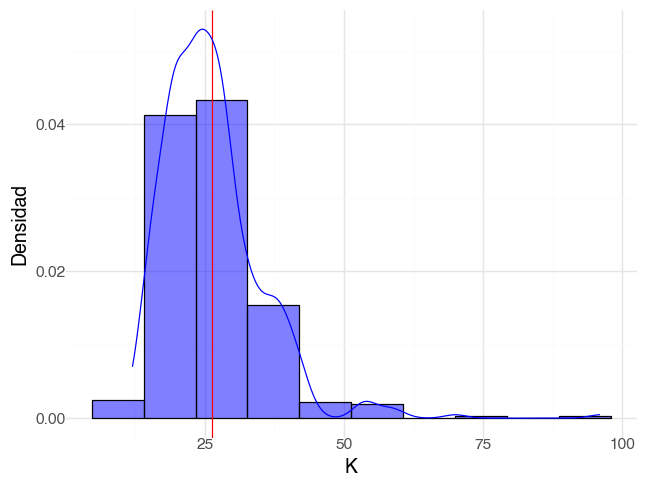

In [4]:
(p9.ggplot(datos, p9.aes(x = myvar0, y = p9.after_stat('density'))) + 
  p9.geom_histogram(bins = 10, color = 'black', fill = 'blue', alpha = .5) + 
  p9.geom_vline(xintercept = datos[myvar0].mean(), color = 'red') +
  p9.geom_density(color = 'blue') +
  p9.labs(y = 'Densidad'))

In [5]:
transformar = True

if transformar is False:
  myvar = myvar0
else:
  myvar = f"{myvar0}_trans"

## Transformacion de datos

Una opcion es la normalizacion/estandarizacion de la variable a una con media de 0 y desviación estándar de 1, esto se logra utilizando la transformacion de cuantiles (`QuantileTransformer`).

In [6]:
if transformar: 
  data = datos[myvar0].values.reshape(-1,1)
  nq = len(data) if len(data) < 500 else 500
  nst_trans = QuantileTransformer(n_quantiles=nq, output_distribution='normal').fit(data)
  var_z = nst_trans.transform(data)
  # datos[myvar] = var_z

Otra opcion es la transformacion de Box-Cox donde se debe hallar el parametro $\lambda$ para transformar la variable lo mas cercano a una variable normalmente distribuida. La transformacion logaritmica (natural, base $e$) es un caso especial donde $\lambda=0$.

La transformacion de Box-Cox se define como:
$$
\begin{cases}
  \frac{x^\lambda-1}{\lambda} & \text{para } \lambda \neq 0\\
  log(x) & \text{para } \lambda = 0
  \end{cases}
$$

La siguiente tabla muestra los valores mas tipicos de $\lambda$ con su respectiva transformacion, donde tipicamente se usan valores entre -2 y 2, pero puede ir desde -5 a 5.

| $\lambda$ | Transformacion |
|:---------:|:--------------:|
|    -2     |    $1/x^2$     |
|    -1     |     $1/x$      |
|   -0.5    |  $1/\sqrt{x}$  |
|     0     |    $log(x)$    |
|    0.5    |   $\sqrt{x}$   |
|     1     |      $x$       |
|     2     |     $x^2$      |

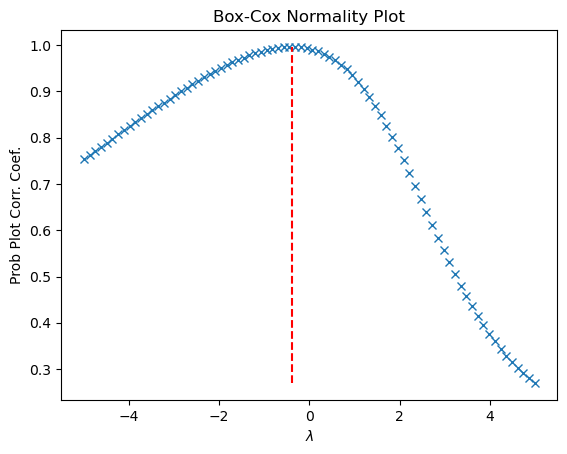

In [7]:
if transformar:

  if (datos[myvar0] <= 0).any():
    raise ValueError("Box-Cox requiere valores estrictamente positivos")

  bc_norm = gs.normalizer.BoxCox(datos[myvar0]) # trasnformador Box-Cox de gstools
  bc_lambda = bc_norm.lmbda
  # bc_lambda = stats.boxcox_normmax(datos[myvar0].values, method='mle')

  fig, ax = plt.subplots()
  bc_normal = stats.boxcox_normplot(datos[myvar0].values, -5, 5, plot=ax)
  ax.plot([bc_lambda,bc_lambda], [bc_normal[1].min(), bc_normal[1].max()], 'r--')
  plt.show()
  # var_bc = stats.boxcox(datos[myvar0].values, lmbda=bc_lambda)
  var_bc = bc_norm.normalize(datos[myvar0].values)
  # datos[myvar] = var_trans
  msg = f"El lambda para {myvar0} es {bc_lambda:.3f}"

lambda_ = bc_lambda if 'bc_lambda' in locals() else None

La funcion `stats.boxcox_normmax` realiza la busqueda de $\lambda$. Adicionalmente se grafica la normalidad de Box-Cox para observar el valor de $\lambda$. La linea punteada roja indica el valor optimo de $\lambda$.

La funcion `gs.normalizer.BoxCox` de `gstools` permite realizar la transformacion y su inversa, así como la obtencion del valor de $\lambda$.

In [8]:
if transformar:
  transformacion = "Box-Cox"  # "Box-Cox" o "Quantile"
  datos[myvar] = var_bc if transformacion == "Box-Cox" else var_z

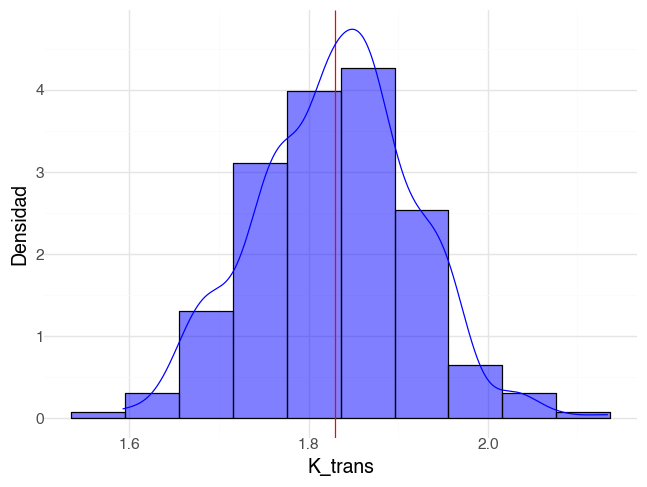

In [9]:
if transformar:  S = datos[myvar].var() # varianza de la variable

(p9.ggplot(datos, p9.aes(x = myvar, y = p9.after_stat('density'))) + 
  p9.geom_histogram(bins = 10, color = 'black', fill = 'blue', alpha = .5) + 
  p9.geom_vline(xintercept = datos[myvar].mean(), color = 'red') +
  p9.geom_density(color = 'blue') +
  p9.labs(y = 'Densidad'))

# Datos espaciales

## Transformar datos en objeto espacial

Se le indica cuales son las columnas que tienen las coordenadas (X,Y) y de conocerse se le asigna el sistema de referencia de coordenadas (CRS) "EPSG:4326" por ejemplo.

In [10]:
x_coord = 'x' # nombre de la columna con coordenadas X
y_coord = 'y' # nombre de la columna con coordenadas Y

datos_sf = gpd.GeoDataFrame(
    datos, geometry=gpd.points_from_xy(datos[x_coord], datos[y_coord]), crs=None
)

## Calculo de distancias

Se calculan las distancias para tener una idea de la distancia maxima y por ende la distancia maxima a la cual calcular el variograma

In [11]:
coords = np.column_stack((datos_sf[x_coord], datos_sf[y_coord]))
dists = pdist(coords)  # pares de distancias

dist_vals = np.round([dists.min(), dists.mean(), dists.max()], 1)
distancias = pd.Series(dist_vals, index=['min', 'media', 'max'])
distancias

min        40.0
media     488.1
max      1310.3
dtype: float64

## Poligono que contiene los datos

In [12]:
outline = datos_sf.union_all().convex_hull
outline_sf = gpd.GeoDataFrame(geometry=[outline], crs=datos_sf.crs)

## Grilla de interpolacion

Grilla donde se quiere determinar la distribucion espacial de la variable de interes. Por lo general dentro del area de influencia de los datos.

In [13]:
minx, miny, maxx, maxy = datos_sf[x_coord].min(), datos_sf[y_coord].min(), datos_sf[x_coord].max(), datos_sf[y_coord].max()

bb = datos_sf.total_bounds
dint = np.ceil(np.max(np.array([bb[2]-bb[0],bb[3]-bb[1]])/len(datos_sf)))

grid_space = dint*2

minx = minx-grid_space
maxx = maxx+grid_space
miny = miny-grid_space
maxy = maxy+grid_space

x_grid = np.arange(minx, maxx, grid_space)
y_grid = np.arange(miny, maxy, grid_space)

grid_x, grid_y = np.meshgrid(x_grid, y_grid)

grid_points = np.vstack([grid_x.ravel(), grid_y.ravel()])
int_points = gs.generate_grid([x_grid, y_grid])

## Distribucion espacial

Vista estatica y dinamica de los datos. El mapa dinamico solo se despliega en version HTML.

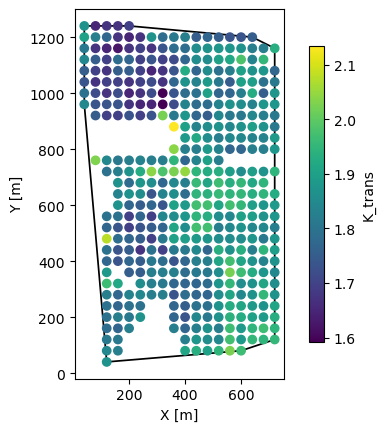

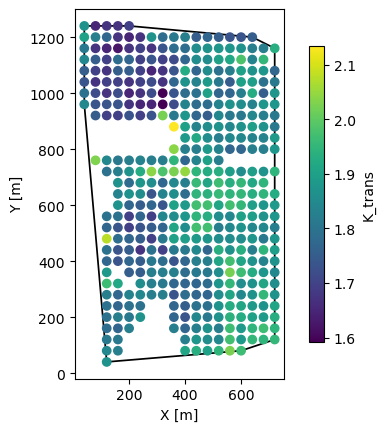

In [15]:
ax = outline_sf.plot(facecolor='none', edgecolor='black', linewidth=1.25)
datos_sf.plot(column=myvar, cmap='viridis', legend=True, legend_kwds={'label': myvar, 'shrink': 0.8}, ax=ax)
ax.set_xlabel(x_map)
ax.set_ylabel(y_map)
plt.show()

# Analisis Geoestadistico

## Variograma omnidireccional

Creacion del variograma. La funcion basica, `gs.vario_estimate`, requiere de los siguientes argumentos:

-   `pos` tupla de coordenadas (x, y) de los puntos
-   `field` datos de interes a interpolar

Argumentos adicionales son:

-   `return_counts` para que devuelva el número de pares de puntos en cada lag
-   < las distancias (lags) a las cuales calcular el variograma
-   `max_dist` la distancia máxima a considerar
-   `bin_no` el número de lags a utilizar
-   `normalizer` si se usa Box-Cox, se pasa el objeto `bc_norm` creado anteriormente

Se usa `bin_edges` o alguna combinación de `max_dist` y/o `bin_no`.

In [16]:
pos = (datos[x_coord], datos[y_coord])
field = datos[myvar0] if transformar is False or transformacion == "Box-Cox" else datos[myvar]
bins = np.linspace(distancias['min']/4, distancias['max']/2, 20)
bins_n = 15
max_lag = distancias['max']/2

In [17]:
bin_center, gamma, npair = gs.vario_estimate(
  pos, 
  field, 
  bin_edges=None, 
  return_counts=True, 
  bin_no=bins_n, 
  max_dist=max_lag,
  normalizer=bc_norm if transformar and transformacion == "Box-Cox" else None
  )

dat_vgm = pd.DataFrame({'lag': bin_center, 'gamma': gamma, 'npair': npair})

In [ ]:
(p9.ggplot(dat_vgm, p9.aes(x = 'lag', y = 'gamma')) + 
  # p9.geom_point(p9.aes(size = 'npair')) +
  p9.geom_point(size = 3) + 
  p9.labs(x = x_var, y = y_var) +
  p9.geom_hline(yintercept = S, color = 'red', linetype = 'dashed') +
  # p9.geom_text(p9.aes(label = 'npair'), nudge_y = 0.03, size = 8) +
  p9.ylim(0, max(dat_vgm['gamma'])*1.05) +
  p9.xlim(0, max(dat_vgm['lag'])))

## Mapa de la superficie del variograma

Representacion en 2D de la variable donde:

-   `nxlag`, `nylag`: son el numero de lags a usar
-   `dxlag`, `dylag`: son el tamanho del celda

In [ ]:
tmin = -9999.
tmax = 9999.
nxlag = nylag = 10
dxlag = dylag = 50
minnp = 1
isill = 1

vmap, npmap = geostats.varmapv(datos_sf,x_coord,y_coord,myvar,tmin,tmax,nxlag,nylag,dxlag,dylag,minnp,isill)

In [ ]:
# vmap, npmap, dxlag, dylag are assumed available
ny, nx = vmap.shape

# centers relative to map center (use (nx-1)/2 so centers are symmetric for both even/odd sizes)
x_centers = (np.arange(nx) - (nx - 1) / 2.0) * dxlag
y_centers = (np.arange(ny) - (ny - 1) / 2.0) * dylag

# compute cell centre coordinates (match how you set xmin/xmax/ymin/ymax and dxlag/dylag)
# x_centers = np.linspace(xmin + dxlag/2, xmax - dxlag/2, nx)
# use top-to-bottom ordering for rows (vmap[0] is top row); flip if your array uses bottom-to-top
# y_centers = np.linspace(ymax - dylag/2, ymin + dylag/2, ny)

XX, YY = np.meshgrid(x_centers, y_centers)

df_vmap = pd.DataFrame({
    "x": XX.ravel(),
    "y": YY.ravel(),
    "gamma": vmap.ravel(),
    "npair": npmap.ravel()
})

df_vmap  # DataFrame

In [ ]:
(p9.ggplot(df_vmap, p9.aes(x = 'x', y = 'y', fill = 'gamma')) +
  p9.geom_raster() + 
  p9.scale_fill_cmap(cmap_name='plasma') +
  p9.labs(x = x_vmap, y = y_vmap, fill = "Semivarianza"))

In [ ]:
xmax = nxlag*dxlag+dxlag/2
ymax = nylag*dylag+dylag/2
xmin = -xmax
ymin = -ymax
vmin = vmap.min()
vmax = vmap.max()
cmap = plt.get_cmap('plasma')

fig, ax = plt.subplots()
GSLIB.pixelplt_st(vmap, xmin, xmax, ymin, ymax, dxlag, vmin, vmax, "Mapa variograma", x_vmap, y_vmap, 'Semivarianza', cmap)
plt.show()

## Variogramas direccionales

Variogramas en diferentes direcciones donde se modifican unicamente los siguientes parametros, donde las direcciones se tienen que dar en radianes:

-   `angles`: direcciones en las cuales se va a calcular el variograma
-   `angles_tol`: tolerancia angular, usualmente 22.5

In [ ]:
azi = np.arange(0,180,45)
azi_rad = np.radians(azi)
atol = np.diff(azi[0:2])/2 # mitad de la diferencia entre los angulos
atol_rad = np.radians(atol)

bin_center, gamma_dir, npair = gs.vario_estimate(
  pos, 
  field, 
  bin_edges=None, 
  angles=azi_rad, 
  angles_tol=atol_rad,
  bin_no=bins_n, 
  max_dist=max_lag,
  return_counts=True,
  normalizer=bc_norm if transformar and transformacion == "Box-Cox" else None)

In [ ]:
n_dirs = gamma_dir.shape[0]
n_lags = bin_center.size

dat_vgm2 = pd.DataFrame({
    "lag": np.tile(bin_center, n_dirs),          
    "gamma": gamma_dir.ravel(order="C"),         
    "npair": npair.ravel(order="C"),             
    "dir_hor": np.repeat(azi, n_lags)       
})

dat_vgm2 = dat_vgm2.astype({"dir_hor": "category"})
dat_vgm2 = dat_vgm2[dat_vgm2['npair'] > 0]

In [ ]:
(p9.ggplot(dat_vgm2,p9.aes(x = 'lag', y = 'gamma',
                    color = 'dir_hor', shape = 'dir_hor')) + 
  p9.geom_point(size = 3, alpha=.5) + 
  # p9.geom_line() +
  p9.labs(x = x_var, y = y_var, color = "Direccion", shape = 'Direccion') +
  p9.geom_hline(yintercept = S, color = 'red', linetype = 'dashed') +
  p9.ylim(0, max(dat_vgm2['gamma'])) +
  p9.xlim(0, max(dat_vgm2['lag'])) +
  # p9.facet_wrap('~dir_hor') +
  p9.theme(legend_position="top") +
  p9.scale_color_brewer(type='qual', palette = 2))

## Modelado

### Ejemplo de modelos teoricos

Se muestran los modelos teoricos mas comunes, simulando una estructura con $C_0=0,C_1=10,a=15$, donde $a$ es el rango efectivo. Para el caso de los modelos exponencial (estable) y gaussiano el rango del modelo es $a/3$ y $a/\sqrt{3}$, respectivamente.

In [ ]:
C0 = 0
C1 = 10
a = 15
  
gau_model = gs.Gaussian(dim=2, var=C1, len_scale=a, nugget=C0, rescale=np.sqrt(3))
exp_model = gs.Exponential(dim=2, var=C1, len_scale=a, nugget=C0, rescale=3)
stb_model = gs.Stable(dim=2, var=C1, len_scale=a, nugget=C0, alpha=1.5, rescale=3)
sph_model = gs.Spherical(dim=2, var=C1, len_scale=a, nugget=C0)
circ_model = gs.Circular(dim=2, var=C1, len_scale=a, nugget=C0)

fig, ax = plt.subplots(figsize=(6, 4))

gau_model.plot(ax=ax, label = 'Gaussiano')
exp_model.plot(ax=ax, label = 'Exponencial')
sph_model.plot(ax=ax, label = 'Esférico')
circ_model.plot(ax=ax, label = 'Circular')
stb_model.plot(ax=ax, label = 'Estable')

ax.plot([a, a], [0, C1], color='black', linestyle='--')
ax.set_xlim(0, 25)
ax.legend()
ax.set_xlabel('Distancia')
ax.set_ylabel('Semivarianza')
plt.show()

### Ajuste de variograma teorico

Se escoge el modelo a ajustar de los disponibles de `gs.*`. Se puede utilizar el método `fit_variogram` para ajustar el modelo a los datos, donde se puede activar o desactivar que se ajuste o no el nugget.

In [18]:
fit_model = gs.Spherical(dim=2)
para, pcov, r2 = fit_model.fit_variogram(bin_center, gamma, nugget=True, return_r2=True)
print(fit_model)
print(f"R^2: {r2:.4f}")

Spherical(dim=2, var=0.00612, len_scale=4.31e+02, nugget=0.00195)
R^2: 0.9928


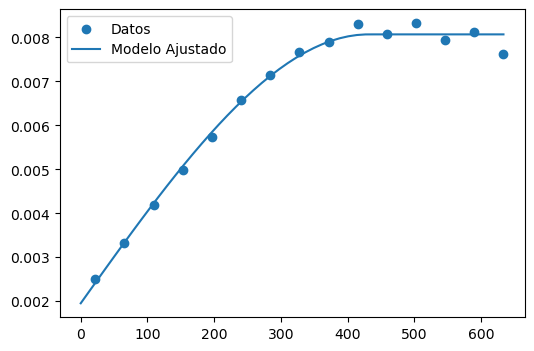

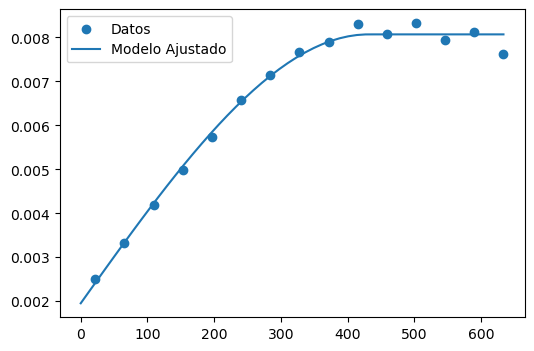

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(bin_center, gamma, label='Datos')
fit_model.plot(x_max=bin_center.max(), ax=ax, label='Modelo Ajustado')
plt.show()

### Validacion cruzada

Una vez escogido el modelo y ajustado a los datos se realiza la validacion cruzada para determinar si es aceptable. Tambien se pueden ajustar diferentes modelos y con los datos de validacion cruzada se determina el mejor.

A continuacion se presentan dos funciones para realizar la validacion cruzada: Leave-One-Out Cross-Validation (LOOCV) y k-fold Cross-Validation (k-fold CV). Para cuando se tienen pocos datos se recomienda usar LOOCV, mientras que para conjuntos de datos mas grandes se puede usar k-fold CV con k=5 o k=10.

In [ ]:
"""
LOOCV con gstools (Kriging ordinario).
Asume:
 - fit_model: modelo de covarianza de gstools ajustado (p. ej., gs.Spherical(...))
 - coords: array-like con forma (n, 2) de las coordenadas de las observaciones
 - values: array-like con forma (n,) de los valores observados
 - devuelve: diccionario con preds, pred_vars, residuals, kcv_df y métricas (RMSE, MAPE, MAE, R2, MSDR, bias)
"""

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

def loocv_gstools(fit_model, coords, values, normalizer=None):
    n = len(values)
    preds = np.empty(n, dtype=float)
    pred_vars = np.empty(n, dtype=float)

    xs = coords[:, 0]
    ys = coords[:, 1]

    for i in range(n):
        mask = np.arange(n) != i
        cond_pos = (xs[mask], ys[mask])
        cond_val = values[mask]

        kr = gs.krige.Ordinary(
            fit_model,
            cond_pos=cond_pos,
            cond_val=cond_val,
            normalizer=normalizer,
            fit_normalizer=False
        )

        # Try calling kr() to predict a point; if your gstools version uses another API,
        # replace next line with the appropriate call (e.g. kr.execute('points', [xs[i]],[ys[i]]))
        pred, var = kr((xs[i], ys[i]))  # pred, var may be scalars or 1‑element arrays

        preds[i] = float(np.asarray(pred).ravel()[0])
        pred_vars[i] = float(np.asarray(var).ravel()[0])

    residuals = values - preds
    rmse = root_mean_squared_error(values, preds)
    mape = mean_absolute_percentage_error(values, preds)
    mae = mean_absolute_error(values, preds)
    r2 = r2_score(values, preds)
    msdr = np.mean(residuals**2 / pred_vars)
    bias = residuals.mean()
    
    kcv_df = pd.DataFrame({
        "observed": values,
        "pred": preds,
        "pred_var": pred_vars,
        "residual": residuals
    })

    return {
        "preds": preds,
        "pred_vars": pred_vars,
        "residuals": residuals,
        "kcv_df": kcv_df,
        "rmse": rmse,
        "mape": mape,
        "mae": mae,
        "r2": r2,
        "msdr": msdr,
        "bias": bias
    }

In [21]:
"""
k-fold CV for gstools Ordinary kriging.
 - fit_model: modelo de covarianza de gstools ajustado (p. ej., gs.Spherical(...))
 - coords: array-like con forma (n, 2) de las coordenadas de las observaciones
 - values: array-like con forma (n,) de los valores observados
 - devuelve: diccionario con preds, pred_vars, residuals, kcv_df y métricas (RMSE, MAPE, MAE, R2, MSDR, bias)
"""
    
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

def kfold_cv_gstools(fit_model, coords, values, k=5, normalizer=None, shuffle=True, random_state=None):

    coords = np.asarray(coords)
    values = np.asarray(values, dtype=float)
    n = len(values)

    preds = np.full(n, np.nan)
    pred_vars = np.full(n, np.nan)

    xs = coords[:, 0]
    ys = coords[:, 1]

    kf = KFold(n_splits=k, shuffle=shuffle, random_state=random_state)
    for train_idx, test_idx in kf.split(coords):
        cond_pos = (xs[train_idx], ys[train_idx])
        cond_val = values[train_idx]

        kr = gs.krige.Ordinary(
            fit_model,
            cond_pos=cond_pos,
            cond_val=cond_val,
            normalizer=normalizer,
            fit_normalizer=False
        )

        pred, var = kr((xs[test_idx], ys[test_idx]))  # batch predict
        pred = np.asarray(pred).ravel()
        var = np.asarray(var).ravel()

        preds[test_idx] = pred
        pred_vars[test_idx] = var

    residuals = values - preds

    rmse = np.sqrt(mean_squared_error(values, preds))
    mae = mean_absolute_error(values, preds)
    mape = mean_absolute_percentage_error(values, preds)
    r2 = r2_score(values, preds)

    valid = pred_vars > 0
    msdr = np.nan if valid.sum() == 0 else np.mean(residuals[valid]**2 / pred_vars[valid])

    bias = np.nanmean(residuals)

    kcv_df = pd.DataFrame({
        "observed": values,
        "pred": preds,
        "pred_var": pred_vars,
        "residual": residuals
    })

    return {
        "preds": preds,
        "pred_vars": pred_vars,
        "residuals": residuals,
        "kcv_df": kcv_df,
        "rmse": rmse,
        "mape": mape,
        "mae": mae,
        "r2": r2,
        "msdr": msdr,
        "bias": bias
    }

In [ ]:
results = loocv_gstools(
  fit_model, 
  coords, 
  datos[myvar], 
  normalizer=bc_norm if transformar and transformacion=="Box-Cox" else None
  )

In [22]:
results = kfold_cv_gstools(
  fit_model, 
  coords, 
  datos[myvar], 
  k=10,
  normalizer=bc_norm if transformar and transformacion=="Box-Cox" else None,random_state=0
  )

In [23]:
print(f"RMSE: {results['rmse']:<.4f}")
print(f"MAPE: {results['mape']:<.4f}")
print(f"MAE: {results['mae']:<.4f}")
print(f"R^2: {results['r2']:<.4f}")
print(f"MSDR: {results['msdr']:<.4f}")
print(f"Bias: {results['bias']:<.4f}")

RMSE: 0.0540
MAPE: 0.0217
MAE: 0.0398
R^2: 0.6143
MSDR: 0.9607
Bias: 0.0014


In [ ]:
kcv_df = results['kcv_df']

In [ ]:
(p9.ggplot(kcv_df, p9.aes('pred', 'observed')) + 
  p9.geom_point(color = "blue", size = 1.25) + 
  # p9.coord_fixed() + 
  p9.geom_abline(slope = 1, color = "red") + 
  p9.geom_smooth(se = False, method = 'lm', color = 'green') +
  p9.labs(x = "Predecidos", y = "Observados", 
          subtitle = 'Rojo: linea 1:1, Verde: regresion'))

In [ ]:
(p9.ggplot(kcv_df, p9.aes('residual')) + 
  p9.geom_histogram(bins = 15, color = 'black', fill = "blue") + 
  p9.labs(x = "Residuales", y = "Fecuencia") + 
  p9.geom_vline(xintercept = kcv_df['residual'].mean(), color = 'red'))

## Interpolacion usando kriging ordinario

Aqui se ha trabajado unicamente con Kriging Ordinario (KO) ya que es el caso mas sencillo y que aplica en la mayoria de las situaciones.

In [ ]:
OK = gs.krige.Ordinary(
  fit_model, 
  cond_pos=pos, 
  cond_val=field,
  normalizer=bc_norm if transformar and transformacion == "Box-Cox" else None,
  fit_normalizer=False
  )

In [ ]:
OK.structured([x_grid, y_grid])

In [ ]:
if transformar and transformacion == "Quantile":
  OK_pred = nst_trans.inverse_transform(OK.field.reshape(-1,1)).reshape(OK.field.shape)
  OK_var = nst_trans.inverse_transform(OK.krige_var.reshape(-1,1)).reshape(OK.krige_var.shape)
  # OK_var = OK_var - OK_var.min()
  OK_std = np.sqrt(OK_var)
else:
  OK_pred = OK.field
  OK_var = OK.krige_var
  # OK_var = OK_var - OK_var.min()
  OK_std = np.sqrt(OK_var)

## Mapas de prediccion y desviacion estandar

### Matplotlib

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Predicción
pcm0 = axes[0].pcolormesh(grid_x, grid_y, OK_pred.T, cmap='viridis')
outline_sf.boundary.plot(ax=axes[0], color='white', linewidth=1.25)
cbar0 = fig.colorbar(pcm0, ax=axes[0], orientation='vertical', label=myvar0)
# axes[0].scatter(datos_sf[x_coord], datos_sf[y_coord], s=1, color="k")
axes[0].set_title('Predicción')
axes[0].set_xlabel(x_map)
axes[0].set_ylabel(y_map)
axes[0].set_aspect("equal")

# Desviación estándar
pcm1 = axes[1].pcolormesh(grid_x, grid_y, OK_std.T, cmap='plasma')
outline_sf.boundary.plot(ax=axes[1], color='white', linewidth=1.25)
cbar1 = fig.colorbar(pcm1, ax=axes[1], orientation='vertical', label='Desviación estándar')
# axes[1].scatter(datos_sf[x_coord], datos_sf[y_coord], s=1, color="k")
axes[1].set_title('Desviación estándar')
axes[1].set_xlabel(x_map)
axes[1].set_ylabel(y_map)
axes[1].set_aspect("equal")

fig.suptitle('Kriging Ordinario - Predicción y Desviación estándar')
plt.tight_layout()
plt.show()

### rasterio

In [ ]:
new_transform = rasterio.transform.from_origin(
    west=minx, 
    north=maxy, 
    xsize=grid_space, 
    ysize=grid_space
)
new_transform

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

img = np.flipud(OK_pred.T)
rasterio.plot.show(img, transform=new_transform, ax=ax, cmap='viridis')
outline_sf.boundary.plot(ax=ax, color='white', linewidth=1.25)
mappable = ax.get_images()[0] 
fig.colorbar(mappable, ax=ax, orientation='vertical', label=myvar0)

# extent = (minx, maxx, miny, maxy)
# im = ax.imshow(OK_pred.T, extent=extent, origin='lower', cmap='viridis', aspect='equal')
# cbar = fig.colorbar(im, ax=ax, orientation='vertical', label=myvar0)

ax.set_xlabel(x_map)
ax.set_ylabel(y_map)

### Objetos xarray

#### DataArray

In [ ]:
y_grid_xr = np.flip(y_grid)

ras = OK_pred
tipo = 'pred'
archivo_xr = 'figs/krige_xr_' + tipo + '.tif'

da = xr.DataArray(
    data=np.flipud(ras.T),
    dims=["y", "x"],
    coords={
        "x": x_grid,
        "y": y_grid_xr
    },
    attrs={
        "long_name": f"Kriging Ordinario {tipo}"
    }
)
da # DataArray

# da.rio.write_crs(datos_sf.crs, inplace=True) # asignar CRS si se conoce ej "EPSG:4326"

# da.rio.to_raster(archivo_xr) # exportar GeoTif

Con el DataArray se pueden hacer selecciones similares a las de un DataFrame de pandas, por ejemplo, para obtener el valor maximo:

In [ ]:
print(da.isel(da.argmax(...)))

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
da.plot(ax=ax, cmap='viridis', cbar_kwargs={'label': myvar0})
outline_sf.boundary.plot(ax=ax, color='white', linewidth=1.25)
ax.set_xlabel(x_map)
ax.set_ylabel(y_map)
ax.set_aspect("equal")

#### DataSet

In [ ]:
y_grid_xr = np.flip(y_grid)

# arreglos con la orientacion correcta
pred_arr = np.flipud(OK_pred.T)
var_arr = np.flipud(OK_var.T)
std_arr = np.flipud(OK_std.T)

ds = xr.Dataset(
    {
        "OK_pred": (("y", "x"), pred_arr),
        "OK_var":  (("y", "x"), var_arr),
        "OK_std":  (("y", "x"), std_arr),
    },
    coords={"x": x_grid, "y": y_grid_xr}
)

ds  # Dataset

## DataFrame de resultados y su descripcion

In [ ]:
res_dict = {
    'pred': OK_pred.ravel(),
    'var': OK_var.ravel(),
    'std': OK_std.ravel()
}
res_df = pd.DataFrame(res_dict)
res_df

In [ ]:
res_df.describe()

# GeoTifs 

## Exportar rasterio

In [ ]:
ras = OK_pred
tipo = 'pred'
archivo = 'figs/krige_' + tipo + '.tif'

with rasterio.open(
    archivo, 
    'w', 
    driver='GTiff',
    height=ras.T.shape[0],
    width=ras.T.shape[1],
    count=1,
    dtype=ras.dtype,
    crs=datos_sf.crs,
    transform=new_transform
) as dst:
    dst.write(np.flipud(ras.T), 1)

print(f"Raster guardado en: {archivo}")

## Revisar

In [ ]:
src = rasterio.open(archivo)

fig, ax = plt.subplots(figsize=(6, 5))

rasterio.plot.show(src, ax=ax, cmap='viridis')
mappable = ax.get_images()[0] 
fig.colorbar(mappable, ax=ax, orientation='vertical')